Import

In [13]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

**Data Processing**

Reading Files

In [14]:
essays = pd.read_csv('kdd-cup-2014-predicting-excitement-at-donors-choose/data/essays.csv')
outcomes = pd.read_csv('kdd-cup-2014-predicting-excitement-at-donors-choose/data/outcomes.csv')
projects = pd.read_csv('kdd-cup-2014-predicting-excitement-at-donors-choose/data/projects.csv')
donations = pd.read_csv('kdd-cup-2014-predicting-excitement-at-donors-choose/data/donations.csv')

Merging

In [15]:
combined = projects.merge(outcomes,how='inner',on='projectid').merge(essays,how='inner',on='projectid')

In [16]:
combined.isna().sum()

projectid                                              0
teacher_acctid_x                                       0
schoolid                                               0
school_ncesid                                      38848
school_latitude                                        0
school_longitude                                       0
school_city                                            0
school_state                                           0
school_zip                                             4
school_metro                                       75488
school_district                                      922
school_county                                         17
school_charter                                         0
school_magnet                                          0
school_year_round                                      0
school_nlns                                            0
school_kipp                                            0
school_charter_ready_promise   

Preparing the Data

In [17]:
#dropping columns that are not important such as teacher account id
#dropping columns with too many categories such as school city

columns = ['projectid','school_state','school_metro','school_magnet','school_nlns',
           'school_kipp','school_charter','school_charter_ready_promise','teacher_teach_for_america',
           'teacher_ny_teaching_fellow','primary_focus_subject','primary_focus_area',
           'resource_type','poverty_level','grade_level','total_price_excluding_optional_support',
           'total_price_including_optional_support','students_reached','eligible_double_your_impact_match',
           'eligible_almost_home_match','date_posted','fully_funded','short_description','need_statement','essay']

data = combined[columns]

In [18]:
#outcomes to binary

binary_map = {'f':0,'t':1}
data['fully_funded'] = data['fully_funded'].map(binary_map)

C:\Users\yzhen\AppData\Local\Temp\ipykernel_15672\1205162642.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['fully_funded'] = data['fully_funded'].map(binary_map)


In [19]:
#capitalize states

data['school_state'] = data['school_state'].str.upper()

C:\Users\yzhen\AppData\Local\Temp\ipykernel_15672\2141012442.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['school_state'] = data['school_state'].str.upper()


Mapping State to Regions

In [20]:
state_to_region = {
    # Northeast
    'CT': 'Northeast', 'ME': 'Northeast', 'MA': 'Northeast', 'NH': 'Northeast',
    'RI': 'Northeast', 'VT': 'Northeast', 'NJ': 'Northeast', 'NY': 'Northeast', 'PA': 'Northeast',
    
    # Midwest
    'IL': 'Midwest', 'IN': 'Midwest', 'MI': 'Midwest', 'OH': 'Midwest', 'WI': 'Midwest',
    'IA': 'Midwest', 'KS': 'Midwest', 'MN': 'Midwest', 'MO': 'Midwest', 'NE': 'Midwest', 'ND': 'Midwest', 'SD': 'Midwest',
    
    # South
    'DE': 'South', 'FL': 'South', 'GA': 'South', 'MD': 'South', 'NC': 'South', 'SC': 'South', 'VA': 'South', 'DC': 'South',
    'WV': 'South', 'AL': 'South', 'KY': 'South', 'MS': 'South', 'TN': 'South', 'AR': 'South', 'LA': 'South',
    'OK': 'South', 'TX': 'South',
    
    # West
    'AZ': 'West', 'CO': 'West', 'ID': 'West', 'MT': 'West', 'NV': 'West', 'NM': 'West',
    'UT': 'West', 'WY': 'West', 'AK': 'West', 'CA': 'West', 'HI': 'West', 'OR': 'West', 'WA': 'West'
}

data['school_state_region'] = data['school_state'].map(state_to_region)

C:\Users\yzhen\AppData\Local\Temp\ipykernel_15672\153282601.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['school_state_region'] = data['school_state'].map(state_to_region)


Sort Chronologically by Post Date

In [21]:
data = data.sort_values(by='date_posted')

Dropping Null

In [22]:
percent_loss = round((data.shape[0] - data.dropna().shape[0])/data.shape[0],4)

print(f'{percent_loss*100}%')

data.dropna(inplace=True)

data.isna().sum()

12.45%


projectid                                 0
school_state                              0
school_metro                              0
school_magnet                             0
school_nlns                               0
school_kipp                               0
school_charter                            0
school_charter_ready_promise              0
teacher_teach_for_america                 0
teacher_ny_teaching_fellow                0
primary_focus_subject                     0
primary_focus_area                        0
resource_type                             0
poverty_level                             0
grade_level                               0
total_price_excluding_optional_support    0
total_price_including_optional_support    0
students_reached                          0
eligible_double_your_impact_match         0
eligible_almost_home_match                0
date_posted                               0
fully_funded                              0
short_description               

Normalizing to Address Outlier Issues

In [23]:
data['students_reached'].describe()

count    542224.000000
mean         98.676901
std        2525.560857
min           0.000000
25%          22.000000
50%          30.000000
75%         100.000000
max      999999.000000
Name: students_reached, dtype: float64

<Axes: xlabel='students_reached_scaled', ylabel='Count'>

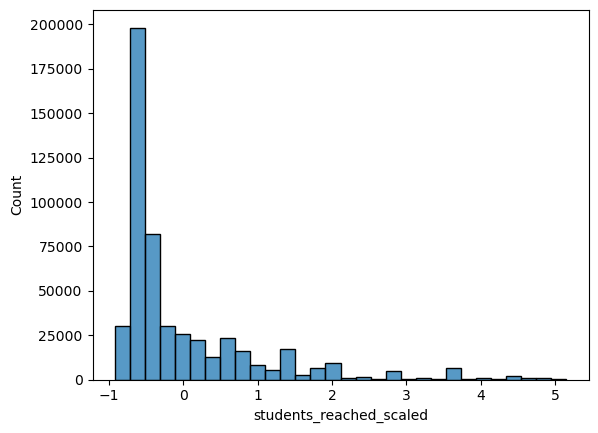

In [24]:
q = data['students_reached'].quantile(0.95)

scaler = StandardScaler()
data_noutliers = data[data['students_reached'] < q]
data_noutliers = data_noutliers[data_noutliers['students_reached'] > 0.0]

data_noutliers['students_reached_scaled'] = scaler.fit_transform(data_noutliers.loc[:,['students_reached']])

sns.histplot(data_noutliers['students_reached_scaled'],bins=30, kde=False)


In [27]:
data_noutliers['total_price_excluding_optional_support'].describe()

count    511166.000000
mean        510.434284
std         752.585133
min           0.000000
25%         266.290000
50%         410.000000
75%         578.080000
max       97974.780000
Name: total_price_excluding_optional_support, dtype: float64

<Axes: xlabel='total_price_excluding_optional_support_scaled', ylabel='Count'>

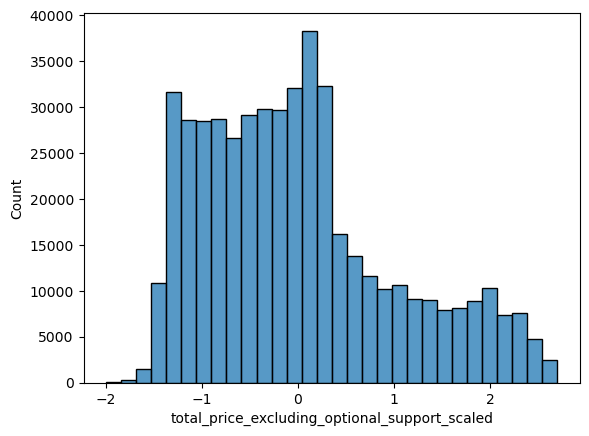

In [28]:
q = data_noutliers['total_price_excluding_optional_support'].quantile(0.95)

data_noutliers = data_noutliers[data_noutliers['total_price_excluding_optional_support'] < q]
data_noutliers = data_noutliers[data_noutliers['total_price_excluding_optional_support'] > 0.0]

data_noutliers['total_price_excluding_optional_support_scaled'] = scaler.fit_transform(data_noutliers.loc[:,['total_price_excluding_optional_support']])

sns.histplot(data_noutliers['total_price_excluding_optional_support_scaled'],bins=30, kde=False)

In [29]:
data_noutliers['total_price_excluding_optional_support'].describe()

count    485604.000000
mean        423.541798
std         207.768871
min           9.000000
25%         258.300000
50%         396.280000
75%         529.000000
max         983.380000
Name: total_price_excluding_optional_support, dtype: float64

In [30]:
data.reset_index(drop=True,inplace=True)
data

,projectid,school_state,school_metro,school_magnet,school_nlns,school_kipp,school_charter,school_charter_ready_promise,teacher_teach_for_america,teacher_ny_teaching_fellow,...,total_price_including_optional_support,students_reached,eligible_double_your_impact_match,eligible_almost_home_match,date_posted,fully_funded,short_description,need_statement,essay,school_state_region
0,77558a6eda151deee9a00553f7fccfc7,NY,urban,t,f,f,f,f,f,f,...,279.27,0.0,f,f,2002-09-13,1,I am a first year teacher assigned to the 6th ...,"The cost of this proposal is [price], includin...",I am a first year teacher assigned to the 6th ...,Northeast
1,82e536f14eadf2671a70e03416f695a3,NY,urban,t,f,f,f,f,f,f,...,152.44,0.0,f,f,2002-09-16,1,I just returned from 3 weeks in S. Africa. I w...,"The cost of this proposal is [price], includin...",I just returned from 3 weeks in S. Africa. I ...,Northeast
2,e02da37beb332eb66c2d2ba989c597ad,NY,urban,f,f,f,f,f,f,f,...,1376.83,0.0,f,f,2002-09-17,1,I teach economics to 25 students at Satellite ...,"The cost of this proposal is $1377, including ...",I teach economics to 25 students at Satellite ...,Northeast
3,c7d251ab36c83155af3269afc8df0b63,NY,urban,f,f,f,f,f,f,f,...,315.55,0.0,f,f,2002-09-17,1,Hello! I am a fifth and sixth grade bilingual ...,"The cost of the books, ranging from ""El Castil...",Hello! I am a fifth and sixth grade bilingual ...,Northeast
4,fd5a8eccdbaa72f9d526dd6e97ca063d,NY,urban,f,f,f,f,f,t,f,...,475.61,0.0,f,f,2002-09-17,1,"Hi, my name is Sara Shenkan and I am a 4th gra...","The cost of this proposal is $476, including s...","Hi, my name is Sara Shenkan and I am a 4th gra...",Northeast
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
542219,f820ef3537f4445b0716244fae36f763,ID,urban,f,f,f,f,f,f,f,...,326.32,30.0,f,f,2013-12-31,0,Math and reading are two separate subjects in ...,My students need a large range of math stories...,Math and reading are two separate subjects in ...,West
542220,95ee208a51831edffa7cc2e0aa3e83cd,AZ,urban,f,f,f,f,f,f,f,...,238.05,98.0,f,f,2013-12-31,1,Remember the first book you ever loved? How yo...,My students need books to improve their readin...,Remember the first book you ever loved? How yo...,West
542221,383500f017fea60562ba737b051e1d21,MN,suburban,f,f,f,f,f,f,f,...,632.35,29.0,f,f,2013-12-31,1,"I will be honest with you, I'm horrible at pre...",My students need funding for a workshop at The...,"I will be honest with you, I'm horrible at pre...",Midwest
542222,efa879a124262ea850736f9f9a54ff7b,CA,rural,f,f,f,f,f,f,f,...,1222.45,22.0,f,f,2013-12-31,0,"My students are curious, not only about lesson...",My students need expenses for admission and tr...,"My students are curious, not only about lesson...",West


In [31]:
data_noutliers.reset_index(drop=True,inplace=True)
data_noutliers

,projectid,school_state,school_metro,school_magnet,school_nlns,school_kipp,school_charter,school_charter_ready_promise,teacher_teach_for_america,teacher_ny_teaching_fellow,...,eligible_double_your_impact_match,eligible_almost_home_match,date_posted,fully_funded,short_description,need_statement,essay,school_state_region,students_reached_scaled,total_price_excluding_optional_support_scaled
0,e05428ddfb30e295844feb11b9d33553,NY,urban,f,f,f,f,f,f,f,...,f,f,2003-06-19,1,"I am a first grade teacher at PS 7, Abraham Li...","The cost of a Language Center, purchased at ww...","I am a first grade teacher at PS 7, Abraham Li...",Northeast,-0.624775,0.724162
1,16605cd564a9611768636b5d0925cb9f,NY,urban,f,f,f,f,f,f,t,...,f,f,2003-07-09,1,"I am a third grade teacher at PS 169, a title ...",The cost of 28 book titles about the continent...,"I am a third grade teacher at PS 169, a title ...",Northeast,-0.244248,-0.795316
2,b3d9d45512362d48ba2b701ac7b87d11,NY,urban,f,f,f,f,f,f,f,...,f,f,2003-08-16,1,I am a second grade teacher in a Title I schoo...,The cost for a supply of prizes such as pencil...,I am a second grade teacher in a Title I schoo...,Northeast,-0.548670,-0.898412
3,67d25016a34607c3284f05e343bca777,NY,urban,f,f,f,f,f,f,f,...,f,f,2003-09-01,1,Hello. I am a third grade teacher at P.S.169. ...,"The cost of a Rotating Wire Book Rack is $287,...",Hello. I am a third grade teacher at P.S.1...,Northeast,-0.624775,-0.909289
4,3710a8c738487f7eafc2c903a2f46cb2,NY,urban,f,f,f,f,f,f,f,...,f,f,2003-09-08,1,"I am a music teacher, turned third grade teach...","The cost of creating a library, complete with ...","I am a music teacher, turned third grade teach...",Northeast,-0.442122,2.379320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
485599,a0e839f24645e3d6dcbd327f8441b043,NY,urban,f,f,f,f,f,f,f,...,f,f,2013-12-31,1,"On a typical day in my classroom, special need...",My students need an assortment of basic art su...,"On a typical day in my classroom, special need...",Northeast,-0.015932,0.691337
485600,f820ef3537f4445b0716244fae36f763,ID,urban,f,f,f,f,f,f,f,...,f,f,2013-12-31,0,Math and reading are two separate subjects in ...,My students need a large range of math stories...,Math and reading are two separate subjects in ...,West,-0.472564,-0.703532
485601,95ee208a51831edffa7cc2e0aa3e83cd,AZ,urban,f,f,f,f,f,f,f,...,f,f,2013-12-31,1,Remember the first book you ever loved? How yo...,My students need books to improve their readin...,Remember the first book you ever loved? How yo...,West,0.562469,-1.064654
485602,383500f017fea60562ba737b051e1d21,MN,suburban,f,f,f,f,f,f,f,...,f,f,2013-12-31,1,"I will be honest with you, I'm horrible at pre...",My students need funding for a workshop at The...,"I will be honest with you, I'm horrible at pre...",Midwest,-0.487785,0.548486
